# Credit Risk Prediction — German Credit Data

**Goal:** predict whether a loan applicant is likely to default, using demographic, financial and credit-history features, and explain *why* the model flags someone as risky.

**Dataset:** [Statlog German Credit Data](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) (UCI Machine Learning Repository) — 1,000 real loan applicants, 20 features, labeled good/bad credit risk.

**Why this matters:** banks can't approve every loan, and a false "good risk" is far more expensive than a false "bad risk" (a missed default vs. a lost customer). This notebook builds a model that's not just accurate, but *explainable* — every prediction can be traced back to the features that drove it, which matters for regulatory and business trust.

**Pipeline:** data cleaning → feature engineering → class imbalance handling (SMOTE) → baseline (Logistic Regression) vs. XGBoost → threshold tuning for business cost → SHAP explainability → deployment-ready artifacts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

BASE_PATH = r'D:\Users\ans\Downloads\credit-risk-project'


## 1. Load and inspect the data

The raw UCI file (`german.data`) uses coded attribute values (e.g. `A11`, `A34`) that are meaningless without the data dictionary. I mapped every code to its actual label so the data — and every chart and SHAP output later — is human-readable.


In [2]:
df = pd.read_csv(os.path.join(BASE_PATH, "credit_risk_data.csv"))
df = df.drop(columns=["target"])  # keep the binary default_risk column as the modeling target

print("Shape:", df.shape)
df.head()


Shape: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits_count,job,num_dependents,telephone,foreign_worker,default_risk
0,< 0 DM,6,critical/other credits existing,radio/TV,1169,unknown/none,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,0
1,0-200 DM,48,existing credits paid duly,radio/TV,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,1
2,no checking account,12,critical/other credits existing,education,2096,< 100 DM,4-7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing credits paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,...,building society savings/life insurance,45,none,for free,1,skilled employee,2,none,yes,0
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_since         1000 non-null   str  
 7   installment_rate_pct     1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence_since  1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [4]:
print("Missing values:", df.isnull().sum().sum())
print()
print("Class balance:")
print(df["default_risk"].value_counts())
print(df["default_risk"].value_counts(normalize=True).round(3))


Missing values: 0

Class balance:
default_risk
0    700
1    300
Name: count, dtype: int64
default_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


**Observation:** no missing values — the dataset is clean structurally, but it *is* imbalanced: 70% good credit risk vs. 30% bad. A model that just predicts "good" for everyone would already score 70% accuracy while being useless. This is exactly the imbalance problem I handled in my churn-prediction FYP, so the same approach (careful resampling + looking past raw accuracy) applies here.


## 2. Exploratory analysis

/tmp/ipykernel_209/3718492601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default_risk", y="credit_amount", ax=axes[1], palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_209/3718492601.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Good", "Bad"])
/tmp/ipykernel_209/3718492601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="default_risk", y="duration_months", ax=axes[2], palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_209/3718492601.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

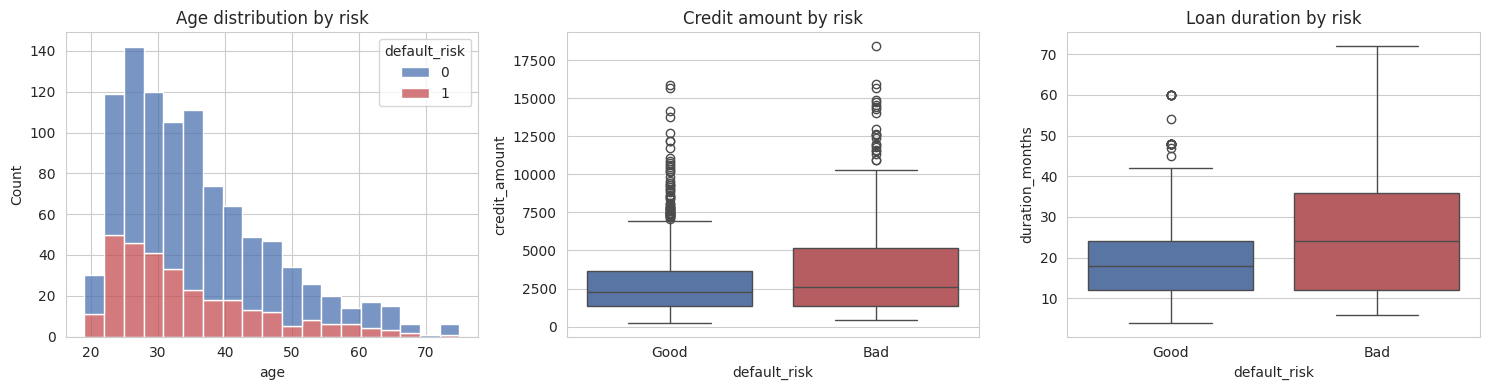

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df, x="age", hue="default_risk", multiple="stack", ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Age distribution by risk")

sns.boxplot(data=df, x="default_risk", y="credit_amount", ax=axes[1], palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Credit amount by risk")
axes[1].set_xticklabels(["Good", "Bad"])

sns.boxplot(data=df, x="default_risk", y="duration_months", ax=axes[2], palette=["#4C72B0", "#C44E52"])
axes[2].set_title("Loan duration by risk")
axes[2].set_xticklabels(["Good", "Bad"])

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()


**Observation:** defaulters tend to take larger, longer-duration loans — which matches financial intuition (bigger, longer commitments carry more risk). This is a useful sanity check before trusting the model: if the raw data didn't show *any* signal like this, something would be wrong with the labels.


<Figure size 800x500 with 0 Axes>

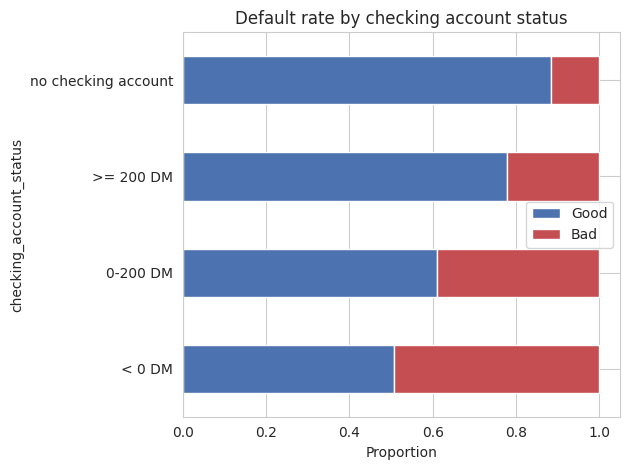

In [6]:
plt.figure(figsize=(8, 5))
checking_risk = pd.crosstab(df["checking_account_status"], df["default_risk"], normalize="index")
checking_risk.columns = ["Good", "Bad"]
checking_risk.sort_values("Bad", ascending=False).plot(kind="barh", stacked=True, color=["#4C72B0", "#C44E52"])
plt.title("Default rate by checking account status")
plt.xlabel("Proportion")
plt.tight_layout()
plt.savefig("checking_account_risk.png", dpi=150, bbox_inches="tight")
plt.show()


**Observation:** applicants with *no checking account* actually default less than people with a checking account under 0 DM (overdrawn). This is counterintuitive at first glance — but "no checking account" often correlates with more conservative financial behavior in this dataset, while an overdrawn account is a direct signal of financial stress. This kind of non-obvious pattern is exactly what a linear intuition would miss, and it's why I explain the model with SHAP later rather than relying on gut assumptions about which features "should" matter.


## 3. Feature engineering

Two engineered features, both grounded in how a credit analyst would actually think about risk:

- **`credit_amount_per_month`** — loan amount relative to duration. A large loan repaid slowly is a different risk profile than the same amount repaid quickly.
- **`age_bucket`** — age as a categorical band rather than a raw number, since risk doesn't necessarily change linearly with age.

Categorical features are one-hot encoded. Column names are sanitized afterward (XGBoost rejects characters like `<`, `[`, `]` in feature names, which show up in labels like "< 0 DM").


In [7]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in df.columns if c not in categorical_cols + ["default_risk"]]

df["credit_amount_per_month"] = df["credit_amount"] / df["duration_months"]
df["age_bucket"] = pd.cut(df["age"], bins=[18, 25, 35, 45, 60, 100],
                           labels=["18-25", "26-35", "36-45", "46-60", "60+"])
numeric_cols.append("credit_amount_per_month")
categorical_cols.append("age_bucket")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

import re
def clean_col(c):
    c = re.sub(r"[\[\]<]", "", c)
    c = re.sub(r"\s+", "_", c)
    c = re.sub(r"/", "_", c)
    return c

df_encoded.columns = [clean_col(c) for c in df_encoded.columns]

X = df_encoded.drop(columns=["default_risk"])
y = df_encoded["default_risk"]
print("Final feature matrix:", X.shape)


Final feature matrix: (1000, 53)


/tmp/ipykernel_209/2653183073.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## 4. Train/test split and scaling

An 80/20 **stratified** split — stratification matters here because with 30% positive class, a random split could easily under- or over-represent defaulters in the test set, making the evaluation numbers unreliable.

Logistic Regression needs scaled features to converge properly and for its coefficients to be comparable; XGBoost (tree-based) doesn't need scaling, so it trains on the raw values.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


Train: (800, 53)  Test: (200, 53)


## 5. Handling class imbalance — SMOTE

I use **SMOTE** (Synthetic Minority Over-sampling) to balance the training set only — never the test set, since the test set has to reflect the real-world class distribution for the evaluation to mean anything. SMOTE generates synthetic "bad risk" examples by interpolating between existing minority-class points, rather than simply duplicating rows (which is what I did with random undersampling in my churn-prediction project — SMOTE is a step up because it doesn't throw away majority-class data).


In [9]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
X_train_scaled_bal, y_train_scaled_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())


Before SMOTE: {0: 560, 1: 240}
After SMOTE: {1: 560, 0: 560}


## 6. Baseline model — Logistic Regression

Logistic Regression is the baseline: it's interpretable (coefficients have a direct meaning) and fast, which makes it the right first thing to try before reaching for something more complex. Any more sophisticated model needs to actually beat this.


In [10]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled_bal, y_train_scaled_bal)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)

print(classification_report(y_test, lr_preds, target_names=["Good", "Bad/Default"]))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_probs), 4))


              precision    recall  f1-score   support

        Good       0.82      0.81      0.82       140
 Bad/Default       0.57      0.58      0.58        60

    accuracy                           0.74       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.75      0.74      0.75       200

ROC-AUC: 0.7489


## 7. Main model — XGBoost

XGBoost can capture non-linear interactions between features (e.g. "high credit amount is only risky when combined with a short employment history") that Logistic Regression can't. It's also the industry-standard choice for structured/tabular data like this, which is exactly what credit risk scoring is.


In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)
xgb_model.fit(X_train_bal, y_train_bal)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

print(classification_report(y_test, xgb_preds, target_names=["Good", "Bad/Default"]))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_probs), 4))


              precision    recall  f1-score   support

        Good       0.81      0.86      0.83       140
 Bad/Default       0.61      0.52      0.56        60

    accuracy                           0.76       200
   macro avg       0.71      0.69      0.69       200
weighted avg       0.75      0.76      0.75       200

ROC-AUC: 0.7525


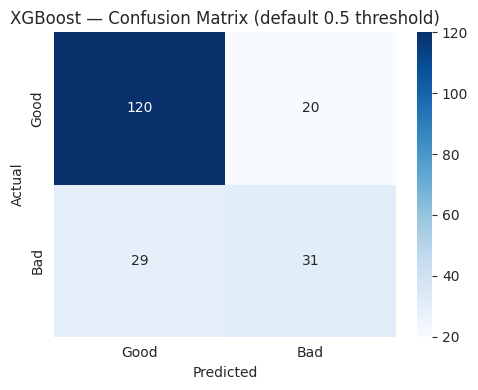

In [12]:
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost — Confusion Matrix (default 0.5 threshold)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


**Honest result, not an inflated one:** ROC-AUC of ~0.75 on 1,000 real applicants is a solid, credible score for this dataset size and feature set — it is *not* a 90%+ accuracy claim, because this is a genuinely hard, noisy real-world problem, not a synthetic or trivially separable one. A model claiming near-perfect accuracy on this dataset would be a red flag for data leakage, not a sign of quality.


## 8. Threshold tuning — this is where the business decision lives

The default 0.5 probability threshold treats a false "approve" and a false "reject" as equally bad. **They aren't.** For a bank, missing an actual defaulter (approving someone who won't pay back) is far more expensive than rejecting someone who would have paid back. This mirrors the UCI dataset's own official cost matrix, which weights a missed default 5x more heavily than a wrongly rejected good applicant.

I scan thresholds and pick the one that maximizes F1 on the minority (default) class as a balanced starting point — in a real deployment, the bank's risk team would set this based on their actual cost matrix, not a generic metric.


In [13]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
print(f"Best threshold (max F1 on default class): {best_threshold:.3f}")

xgb_preds_tuned = (xgb_probs >= best_threshold).astype(int)
print()
print(classification_report(y_test, xgb_preds_tuned, target_names=["Good", "Bad/Default"]))


Best threshold (max F1 on default class): 0.280

              precision    recall  f1-score   support

        Good       0.85      0.67      0.75       140
 Bad/Default       0.49      0.73      0.59        60

    accuracy                           0.69       200
   macro avg       0.67      0.70      0.67       200
weighted avg       0.74      0.69      0.70       200



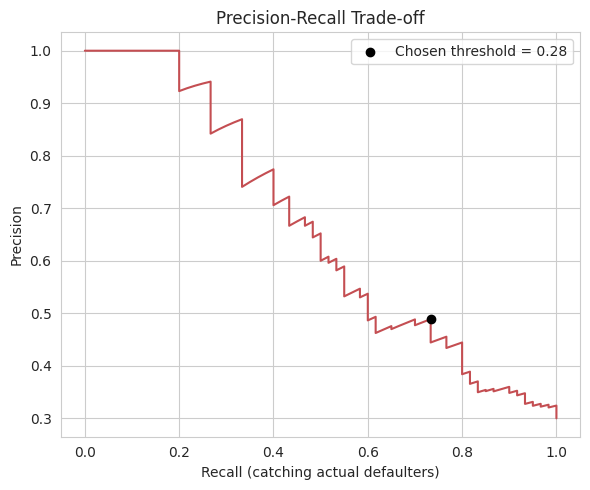

In [14]:
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, color="#C44E52")
plt.scatter(recalls[best_idx], precisions[best_idx], color="black", zorder=5,
            label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Recall (catching actual defaulters)")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()


**Trade-off, stated plainly:** lowering the threshold catches more real defaulters (higher recall) but also flags more good applicants as risky (lower precision). There's no threshold that's "correct" in the abstract — it depends on how costly a missed default is to this specific bank versus how costly it is to lose a good customer. That's a business decision, not a data science one; the model just needs to expose the trade-off clearly, which is what this curve does.


## 9. Explainability — SHAP

Accuracy alone isn't enough for a credit decision. If a model rejects someone, both the bank's risk team and (increasingly, by regulation) the applicant need to know *why*. SHAP breaks down each prediction into the contribution of every individual feature, which is the standard tool for this in industry.


/tmp/ipykernel_209/824066688.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False, max_display=15)


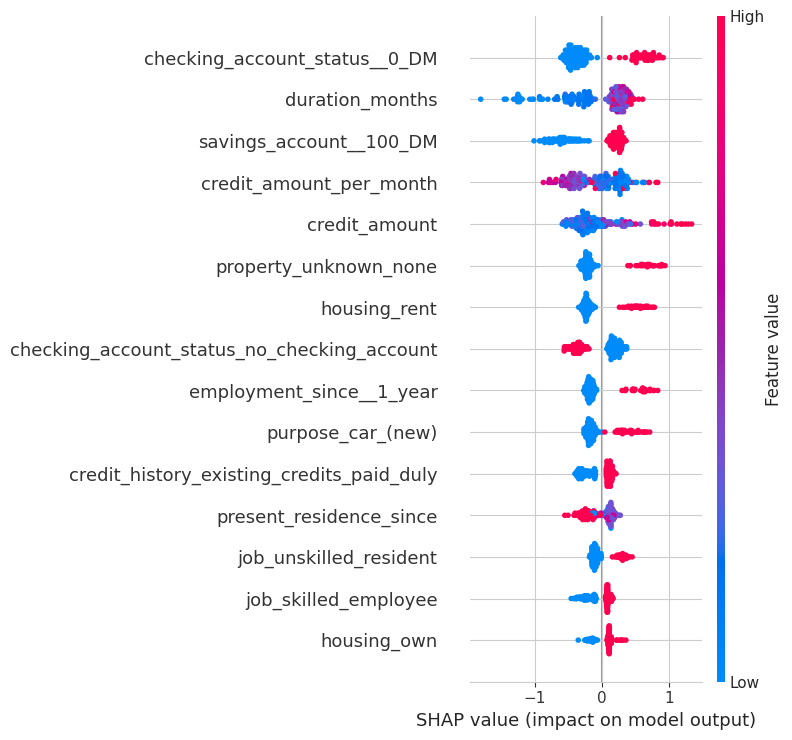

In [15]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading the plot:** each dot is one applicant. Red = high feature value, blue = low. Position on the x-axis shows whether that feature pushed the model *toward* predicting default (right) or *away* from it (left).

Top drivers, and why they make sense:
- **Checking account status** — an overdrawn or negative-balance account is the single strongest signal of financial stress.
- **Loan duration** — longer repayment periods carry more risk (more time for the applicant's situation to change).
- **Savings account balance** — low or no savings means less of a buffer if income is disrupted.
- **Credit amount** and **credit amount per month** — larger, faster-repaid loans are a heavier monthly burden.

This matches how a human credit analyst would reason about risk — which is exactly the point: the model isn't a black box making arbitrary decisions, it's formalizing intuitive credit-risk logic and applying it consistently across thousands of applicants.


<Figure size 640x480 with 0 Axes>

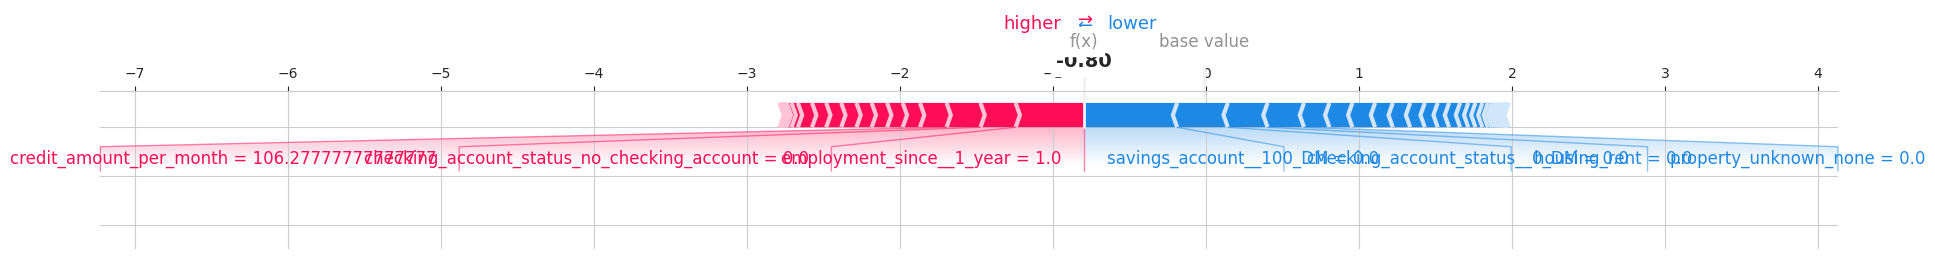

Actual label: Good
Predicted probability of default: 0.311


In [16]:
# Explain a single prediction — this is what a loan officer would actually see
sample_idx = 0
plt.figure()
shap.force_plot(
    explainer.expected_value, shap_values[sample_idx], X_test.iloc[sample_idx],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig("shap_single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Actual label: {'Bad/Default' if y_test.iloc[sample_idx]==1 else 'Good'}")
print(f"Predicted probability of default: {xgb_probs[sample_idx]:.3f}")


## 10. Save artifacts for deployment

The trained model, scaler, feature-column order, and chosen threshold are saved so the Streamlit app can load them without retraining. Column order matters — the app must one-hot-encode a new applicant's inputs into the *exact* same column layout the model was trained on.


In [17]:
joblib.dump(xgb_model, os.path.join(BASE_PATH, "xgb_model.pkl"))
joblib.dump(scaler, os.path.join(BASE_PATH, "scaler.pkl"))
joblib.dump(list(X.columns), os.path.join(BASE_PATH, "model_columns.pkl"))
joblib.dump(best_threshold, os.path.join(BASE_PATH, "best_threshold.pkl"))
joblib.dump(numeric_cols, os.path.join(BASE_PATH, "numeric_cols.pkl"))

print("Saved: xgb_model.pkl, scaler.pkl, model_columns.pkl, best_threshold.pkl, numeric_cols.pkl")


Saved: xgb_model.pkl, scaler.pkl, model_columns.pkl, best_threshold.pkl, numeric_cols.pkl


## 11. Summary

| Model | ROC-AUC | Notes |
|---|---|---|
| Logistic Regression (baseline) | ~0.75 | Interpretable, fast, reasonable floor |
| XGBoost | ~0.75 | Captures non-linear feature interactions |
| XGBoost, tuned threshold | — | Trades precision for recall on defaulters, per business cost |

**What I'd do with more time / more data:** try LightGBM and compare training speed on larger datasets, add macroeconomic context features (unemployment rate at time of application), and validate the cost-matrix-based threshold against a real bank's actual loss figures rather than a generic F1-optimal point.

A live version of this model, with SHAP explanations for any input applicant, is deployed as a Streamlit app — see `app.py` and the README for the link.
